In [46]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [70]:
import importlib

import model
import optimiser
import loss_fn
importlib.reload(loss_fn)
importlib.reload(model)

<module 'model' from '/Users/bhavyashah/Desktop/Linear Regress/model.py'>

In [44]:
y.min()

np.float64(0.14999)

In [47]:
X, y = fetch_california_housing(return_X_y=True)

# We need to normalise or either the grads will shoot up to inf
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [48]:
y = y.reshape(20640,1)

In [49]:
X.shape, y.shape

((20640, 8), (20640, 1))

In [73]:
lr_own = model.LinearRegression(X.shape[1])
n_epochs = 500
lr = 0.05

loss_history = []
r2_history = []

for i in range(n_epochs):
    y_pred = lr_own.predict(X=X)
    loss = loss_fn.compute_loss(y_pred=y_pred, y=y)
    gradw, gradb = loss_fn.compute_grad(X, loss)
    new_w, new_b = optimiser.update_wts(lr_own.w, lr_own.b, grad_w=gradw, grad_b=gradb, lr=lr)
    lr_own.set_params(new_w, new_b)

    loss_history.append(np.mean((y_pred-y)**2))
    r2_history.append(r2_score(y, y_pred))

y_pred = lr_own.predict(X)
residuals = y - y_pred
score = r2_score(y_true=y, y_pred=y_pred)
print(score)

0.606114080403044


In [71]:
lr_closedform = model.LinearRegressionClosedForm()
lr_closedform.fit(X, y)
print(r2_score(y, lr_closedform.predict(X)))

0.606232685199805


In [58]:
sklearn_reg = LinearRegression()
sklearn_reg.fit(X,y)
print(r2_score(y, sklearn_reg.predict(X)))

0.606232685199805


Matplotlib is building the font cache; this may take a moment.


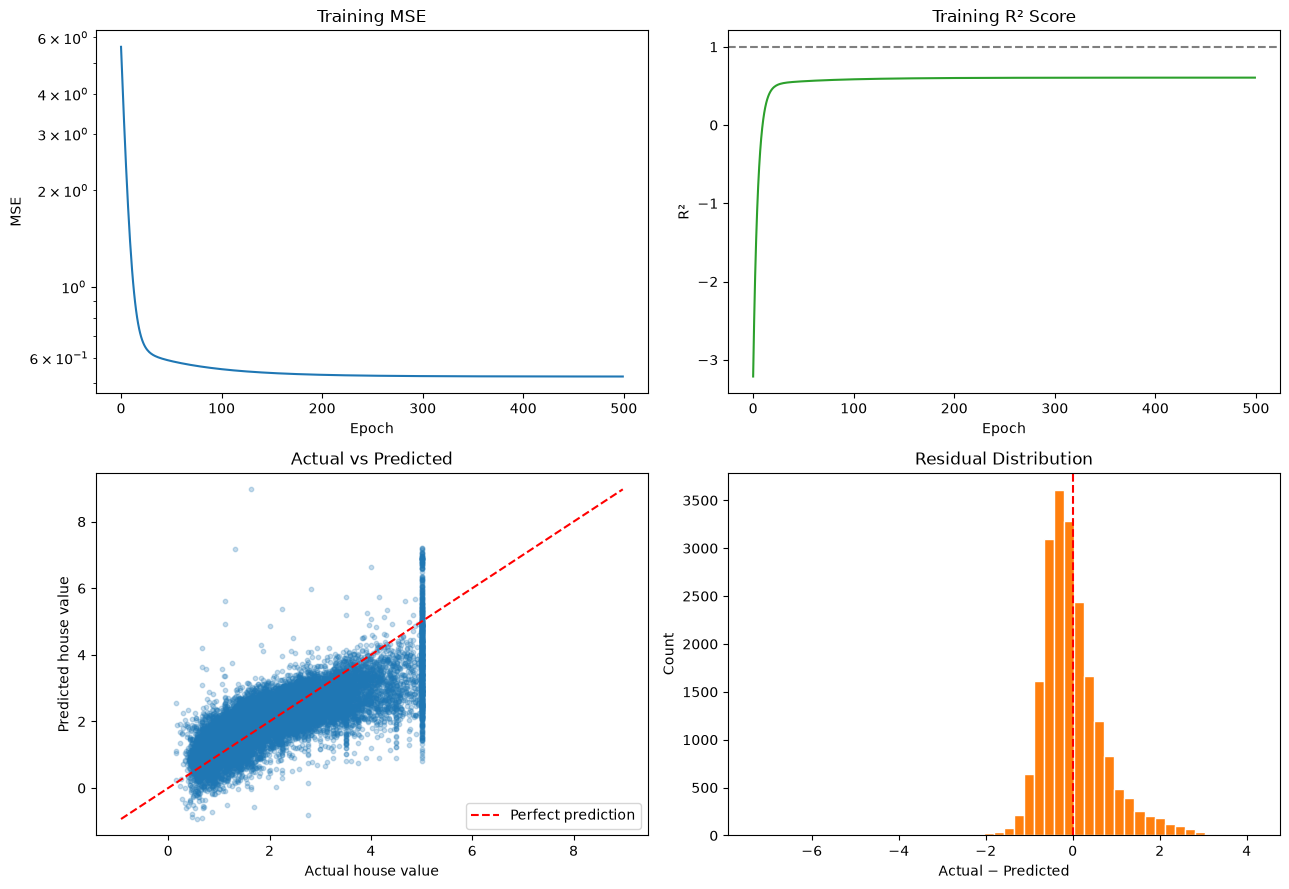

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. MSE learning curve
axes[0, 0].plot(loss_history, color="tab:blue")
axes[0, 0].set_title("Training MSE")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("MSE")
axes[0, 0].set_yscale("log")  # convergence looks much clearer like this

# 2. R² learning curve
axes[0, 1].plot(r2_history, color="tab:green")
axes[0, 1].set_title("Training R² Score")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("R²")
axes[0, 1].axhline(1, linestyle="--", color="black", alpha=0.5)

# 3. Actual vs predicted
axes[1, 0].scatter(y, y_pred, alpha=0.25, s=10)
lower = min(y.min(), y_pred.min())
upper = max(y.max(), y_pred.max())
axes[1, 0].plot([lower, upper], [lower, upper], "r--", label="Perfect prediction")
axes[1, 0].set_title("Actual vs Predicted")
axes[1, 0].set_xlabel("Actual house value")
axes[1, 0].set_ylabel("Predicted house value")
axes[1, 0].legend()

# 4. Residual distribution
axes[1, 1].hist(residuals.ravel(), bins=50, color="tab:orange", edgecolor="white")
axes[1, 1].axvline(0, color="red", linestyle="--")
axes[1, 1].set_title("Residual Distribution")
axes[1, 1].set_xlabel("Actual − Predicted")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()